In [28]:
import sys
sys.path.append('../core')
from utils import *
from nodes import ChemNode
from BFS import BFS
from tree_utils import *
from FeasibilityAnalyzer import *

#### Load necessary databases

In [29]:
# Database files
custom_file = '../data/custom.db'
buyable_file = '../data/sampled_split.db'
excluded_file = '../data/excluded.db'

# Directionality dataset for feasibility assessment
directionality_file = '../data/directionality_dataset.pkl'

# RDenzyme RetroSim files
rdenzyme_file = '../data/rdenzyme_db.pkl'
retrobiocat_file = '../data/retrobiocat_db.pkl'

# Load databases
custom = sqlite3.connect(f'file:{custom_file}', uri=True).cursor()
buyable = sqlite3.connect(f'file:{buyable_file}', uri=True).cursor()
excluded = sqlite3.connect(f'file:{excluded_file}', uri=True).cursor()

# Load retrosim
analyzer = Retrosim(rdenzyme_file, retrobiocat_file)
feas_analyzer = FeasibilityAnalyzer(directionality_file)

#### Run multi-step retrosynthesis analysis

In [30]:
# User input
name = "BDO"
target = "OCCCCO"
max_precursors = 25
max_depth = 3
retrobiocat = False

# Load root and planner
root = ChemNode(canonicalize_smiles(target), 0, None, False, max_precursors, retrobiocat, buyable, custom, excluded, analyzer)
bfs = BFS(root, max_depth)

# Storage File
save_file = f'saved_roots/BFS_{name}_Top{max_precursors}_{"RBC" if retrobiocat else "noRBC"}.pkl'

In [31]:
# Run multi-step planner
bfs.multi_step_planner()

'Search is complete!'

In [32]:
# Get solved paths in tree
paths = generate_paths(root)
print(f"Number of pathways found: {len(paths)}")

# Results in text-format
#for i in range(0, len(paths)):
#    print(f'Path {i}')
#    path_explorer(paths[i])
#    print(" ")

Number of pathways found: 2


In [33]:
# Save full root
file_names = [buyable_file, excluded_file, custom_file, rdenzyme_file, retrobiocat_file]
save_tree(save_file, file_names, root)

#### Display all pathways without feasibility assessment

There are a total of 2 pathways
PATH 1 ==============================
STEP 1/2
https://www.rhea-db.org/rhea/23190


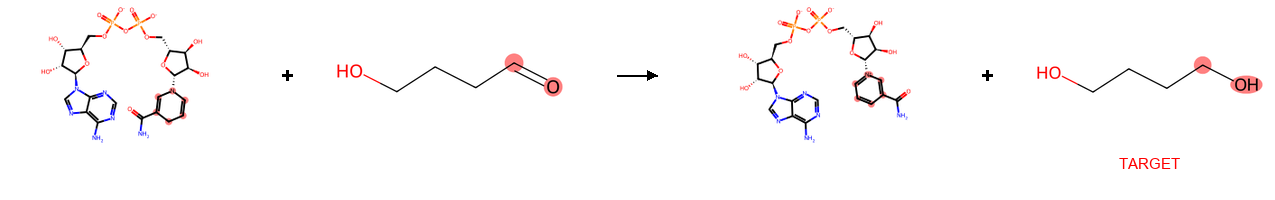

Reaction SMILES: O=CCCCO.NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)([O-])OP(=O)([O-])OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)C=CC1.[H+]>>OCCCCO.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)([O-])OP(=O)([O-])OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)c1

STEP 2/2
https://www.rhea-db.org/rhea/19766


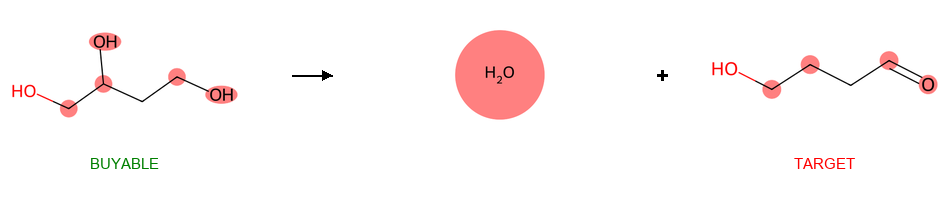

Reaction SMILES: OCCC(O)CO>>O=CCCCO.O

Reactions: ['23190', '19766']

PATH 2 ==============================
STEP 1/3
https://www.rhea-db.org/rhea/23190


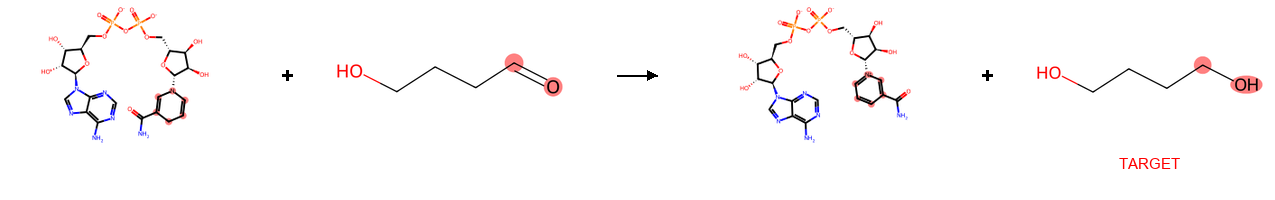

Reaction SMILES: O=CCCCO.NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)([O-])OP(=O)([O-])OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)C=CC1.[H+]>>OCCCCO.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)([O-])OP(=O)([O-])OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)c1

STEP 2/3
https://www.rhea-db.org/rhea/43434


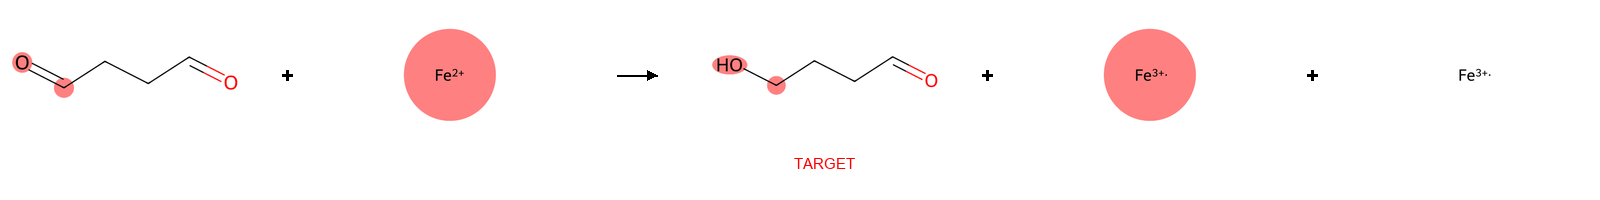

Reaction SMILES: O=CCCC=O.[Fe+2].[H+]>>O=CCCCO.[Fe+3].[Fe+3]

STEP 3/3
https://www.rhea-db.org/rhea/50313


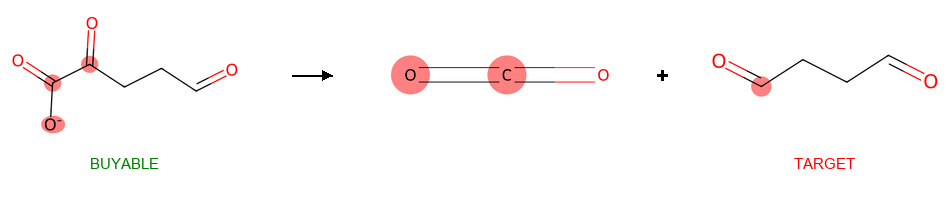

Reaction SMILES: O=CCCC(=O)C(=O)[O-].[H+]>>O=CCCC=O.O=C=O

Reactions: ['23190', '43434', '50313']



In [34]:
display_all_pathways(paths, buyable, custom)

#### Perform feasibility assessment of proposed pathways

In [25]:
# Perform feasibility assessment, then save pathways
feasible_pathways, unfeasible_pathways = feas_analyzer.process_paths_sample(paths)
feas_analyzer.save_pathways(feasible_pathways, unfeasible_pathways, save_file)

Saved both files


In [26]:
# Display feasible pathways
display_feasible_pathways(feasible_pathways, buyable, custom)

0 pathways are feasible


2 pathways are NOT feasible
PATH 1 ==============================

A total of 1 steps were marked as unfeasible
  - Step 2: 19766 (Unknown)

STEP 1/2
https://www.rhea-db.org/rhea/23190


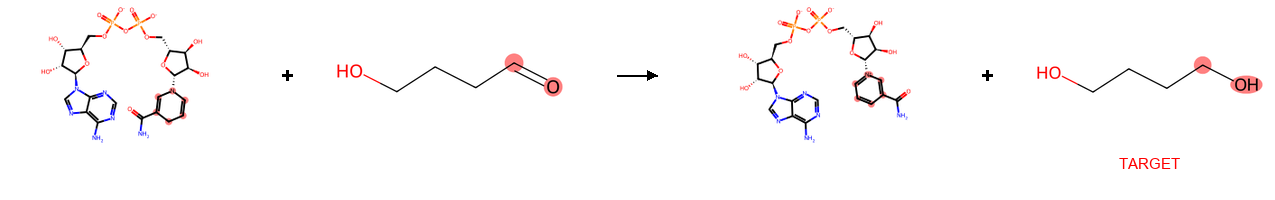

Reaction SMILES: O=CCCCO.NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)([O-])OP(=O)([O-])OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)C=CC1.[H+]>>OCCCCO.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)([O-])OP(=O)([O-])OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)c1

STEP 2/2 NOT FEASIBLE
https://www.rhea-db.org/rhea/19766


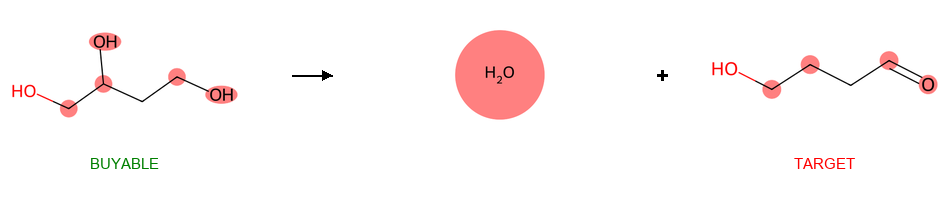

Reaction SMILES: OCCC(O)CO>>O=CCCCO.O

Reactions: ['23190', '19766']

PATH 2 ==============================

A total of 1 steps were marked as unfeasible
  - Step 2: 43434 (No)

STEP 1/3
https://www.rhea-db.org/rhea/23190


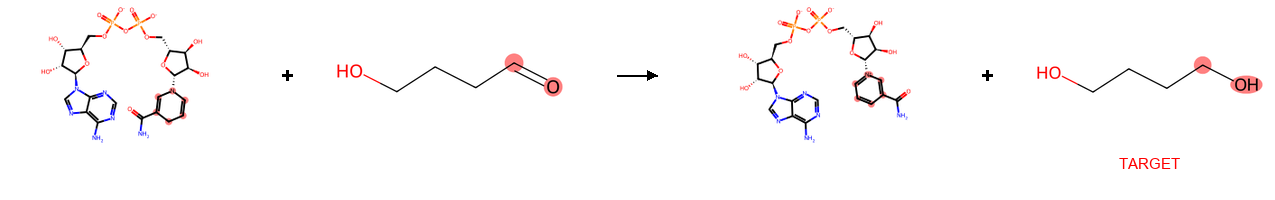

Reaction SMILES: O=CCCCO.NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)([O-])OP(=O)([O-])OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)C=CC1.[H+]>>OCCCCO.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)([O-])OP(=O)([O-])OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)c1

STEP 2/3 NOT FEASIBLE
https://www.rhea-db.org/rhea/43434


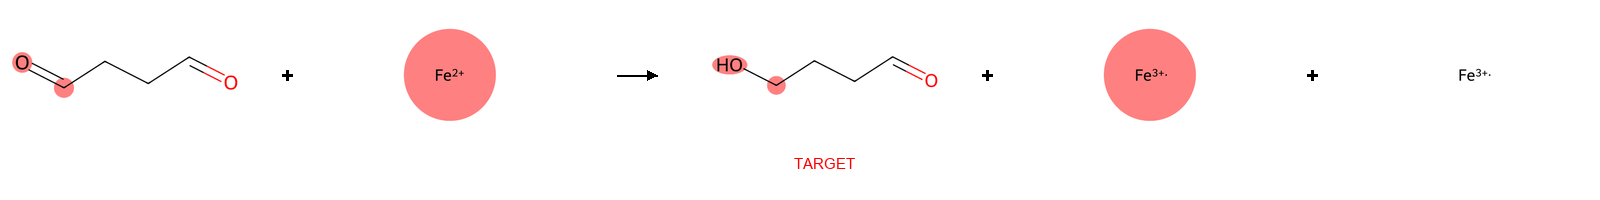

Reaction SMILES: O=CCCC=O.[Fe+2].[H+]>>O=CCCCO.[Fe+3].[Fe+3]

STEP 3/3
https://www.rhea-db.org/rhea/50313


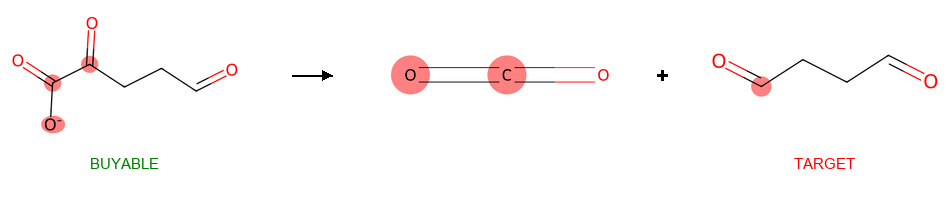

Reaction SMILES: O=CCCC(=O)C(=O)[O-].[H+]>>O=CCCC=O.O=C=O

Reactions: ['23190', '43434', '50313']



In [27]:
# Display unfeasible pathways
display_unfeasible_pathways(unfeasible_pathways, buyable, custom)

Debugging section

In [ ]:
# First step
for idx, react in enumerate(root.reactions):
    print(f'{idx} - Reaction name: {react.reaction_name}')
    for idx2, precursor in enumerate(react.precursors):
        print(f'     {idx2} - Chem {precursor.smiles}, solution: {precursor.solution}')
    print(" ")

In [ ]:
# Second step
snd = root.reactions[3].precursors[0]
for idx, react in enumerate(snd.reactions):
    print(f'{idx} - Reaction name: {react.reaction_name}')
    for idx2, precursor in enumerate(react.precursors):
        print(f'     {idx2} - Chem {precursor.smiles}, solution: {precursor.solution}')
    print(" ")

In [ ]:
# Third Step
trd = snd.reactions[2].precursors[0]
for idx, react in enumerate(trd.reactions):
    print(f'{idx} - Reaction name: {react.reaction_name}')
    for idx2, precursor in enumerate(react.precursors):
        print(f'     {idx2} - Chem {precursor.smiles}, solution: {precursor.solution}')
    print(" ")

In [ ]:
# Fourth Step
frt = trd.reactions[0].precursors[0]
for idx, react in enumerate(frt.reactions):
    print(f'{idx} - Reaction name: {react.reaction_name}')
    for idx2, precursor in enumerate(react.precursors):
        print(f'     {idx2} - Chem {precursor.smiles}, solution: {precursor.solution}')
    print(" ")

In [ ]:
# Fifth Step
fth = frt.reactions[0].precursors[0]
for idx, react in enumerate(fth.reactions):
    print(f'{idx} - Reaction name: {react.reaction_name}')
    for idx2, precursor in enumerate(react.precursors):
        print(f'     {idx2} - Chem {precursor.smiles}, solution: {precursor.solution}')
    print(" ")

In [ ]:
# Sixth Step
six = fth.reactions[5].precursors[0]
for idx, react in enumerate(six.reactions):
    print(f'{idx} - Reaction name: {react.reaction_name}')
    for idx2, precursor in enumerate(react.precursors):
        print(f'     {idx2} - Chem {precursor.smiles}, solution: {precursor.solution}')
    print(" ")